In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wordcloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from wordcloud import WordCloud


# Set visual style for charts
sns.set_theme(style="whitegrid")
print("Libraries are loaded!")

Libraries are loaded!


In [22]:
# 1. Load the data
file_path = "Dataset/spam.csv"
mail_df = pd.read_csv(file_path, encoding='latin-1')

# 2. Clean up the dataframe (Keep only the label and the text)
# Standard spam datasets usually name the columns 'v1' (label) and 'v2' (text)
mail_df = mail_df[['v1', 'v2']]
mail_df.columns = ['Label', 'Message']

# 3. Convert text labels ('ham' / 'spam') into numbers (0 / 1)
mail_df['Is_Spam'] = mail_df['Label'].map({'ham': 0, 'spam': 1})

print("Data is cleaned! Here are the first few rows:")
display(mail_df.head())

Data is cleaned! Here are the first few rows:


,Label,Message,Is_Spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [23]:
# Separate the text messages from the spam flags
raw_msgs = mail_df['Message']
spam_flags = mail_df['Is_Spam']

# Split into 80% training and 20% testing
tr_txt, ts_txt, tr_lbl, ts_lbl = train_test_split(
    raw_msgs, spam_flags, test_size=0.2, random_state=42
)

# Initialize the text-to-number converter
word_converter = TfidfVectorizer(stop_words='english', lowercase=True)

# Transform the training and testing text
tr_features = word_converter.fit_transform(tr_txt)
ts_features = word_converter.transform(ts_txt)

print(f"Training messages: {tr_features.shape[0]}")
print(f"Testing messages: {ts_features.shape[0]}")

Training messages: 4457
Testing messages: 1115


In [24]:
# Initialize and train the Naive Bayes model
spam_filter = MultinomialNB()
spam_filter.fit(tr_features, tr_lbl)

# Predict on the test set
ts_preds = spam_filter.predict(ts_features)

# Calculate Accuracy
acc_pct = accuracy_score(ts_lbl, ts_preds) * 100
print(f"Spam Detection Accuracy: {acc_pct:.2f}%\n")

# Show a detailed breakdown
print("--- Detailed Classification Report ---")
print(classification_report(ts_lbl, ts_preds, target_names=['Not Spam (ham)', 'Spam']))

Spam Detection Accuracy: 96.68%

--- Detailed Classification Report ---
                precision    recall  f1-score   support

Not Spam (ham)       0.96      1.00      0.98       965
          Spam       1.00      0.75      0.86       150

      accuracy                           0.97      1115
     macro avg       0.98      0.88      0.92      1115
  weighted avg       0.97      0.97      0.96      1115



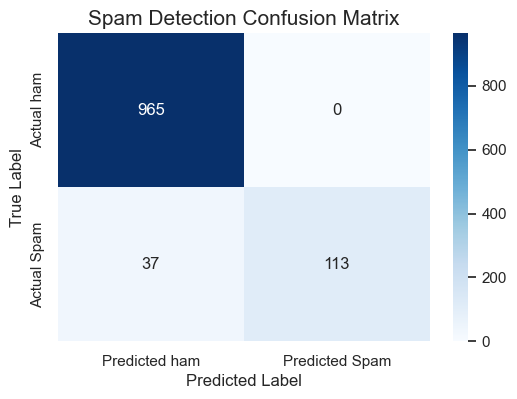

In [25]:
plt.figure(figsize=(6, 4))

# Generate the confusion matrix
conf_mat = confusion_matrix(ts_lbl, ts_preds)

# Plot it using Seaborn's heatmap
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted ham', 'Predicted Spam'],
            yticklabels=['Actual ham', 'Actual Spam'])

plt.title('Spam Detection Confusion Matrix', fontsize=15)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

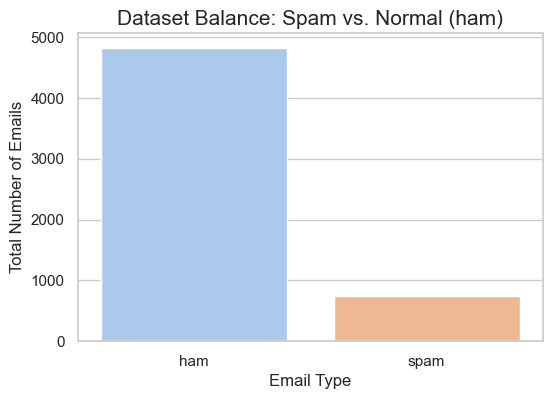

In [26]:
plt.figure(figsize=(6, 4))

# Count how many emails are in each category
sns.countplot(data=mail_df, x='Label', palette='pastel', hue='Label', legend=False)

plt.title('Dataset Balance: Spam vs. Normal (ham)', fontsize=15)
plt.xlabel('Email Type', fontsize=12)
plt.ylabel('Total Number of Emails', fontsize=12)
plt.show()

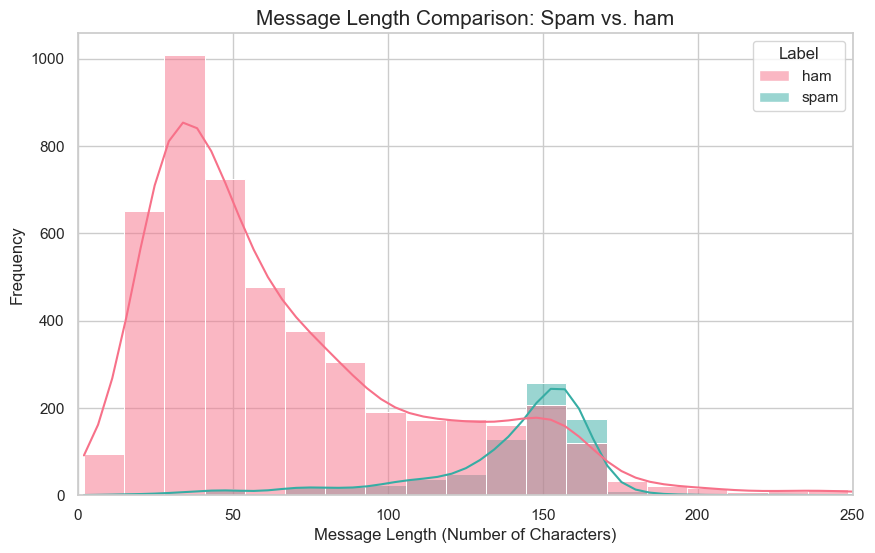

In [27]:
# Creating a new column that count characters in each message
mail_df['Txt_Length'] = mail_df['Message'].apply(len)

plt.figure(figsize=(10, 6))

# Plotting overlapping histograms to compare the lengths
sns.histplot(data=mail_df, x='Txt_Length', hue='Label', bins=70, kde=True, palette='husl')

plt.title('Message Length Comparison: Spam vs. ham', fontsize=15)
plt.xlabel('Message Length (Number of Characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# We limit the X-axis to 250 characters to zoom in on where most of the data is
plt.xlim(0, 250) 
plt.show()

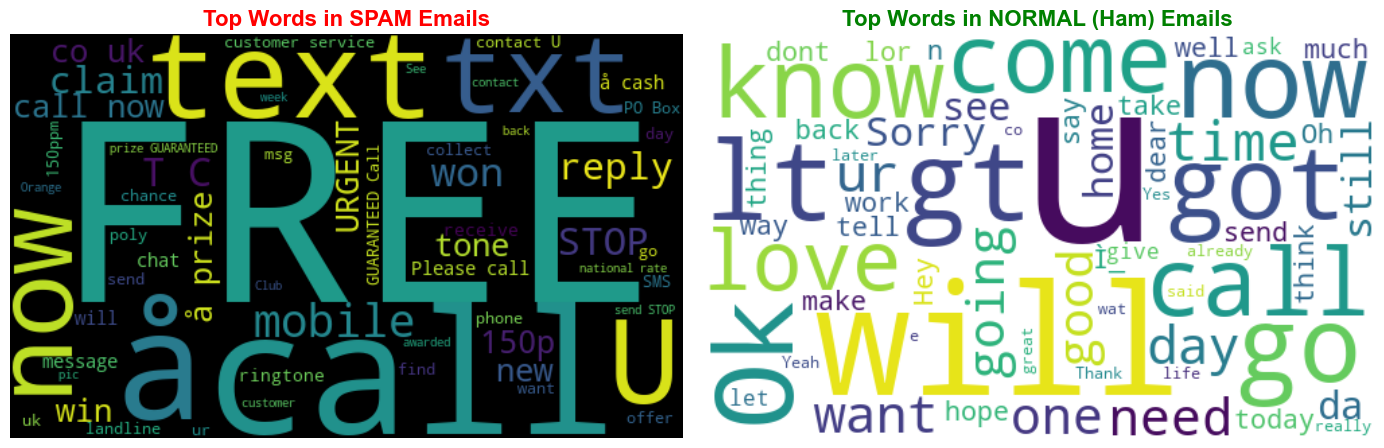

In [28]:
# Grouping texts into two big strings
spam_words_blob = ' '.join(list(mail_df[mail_df['Is_Spam'] == 1]['Message']))
ham_words_blob = ' '.join(list(mail_df[mail_df['Is_Spam'] == 0]['Message']))

# Create the visual clouds
cloud_spam = WordCloud(width=500, height=300, background_color='black', max_words=60).generate(spam_words_blob)
cloud_ham = WordCloud(width=500, height=300, background_color='white', max_words=60).generate(ham_words_blob)

# using side-by-side display
plt.figure(figsize=(14, 6))

# words for Spam Cloud
plt.subplot(1, 2, 1)
plt.imshow(cloud_spam, interpolation='bilinear')
plt.title('Top Words in SPAM Emails', fontsize=16, color='red', fontweight='bold')
plt.axis('off')

# words for ham Cloud
plt.subplot(1, 2, 2)
plt.imshow(cloud_ham, interpolation='bilinear')
plt.title('Top Words in NORMAL (Ham) Emails', fontsize=16, color='green', fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()